# Figure 4.6: Omega Regression Vertical Cross-Section Subplots (P1, P2, and P2-P1 Difference)

This notebook plots vertical cross-sections of omega regression against the standardized Niño 3.4 index in a 2 × 3 subplot grid:
- **Top row (Longitude cross-section)**: longitude-pressure cross-section averaged over 10°S-5°N.
- **Bottom row (Latitude cross-section)**: latitude-pressure cross-section averaged over 95°E-125°E.

Each row shows:
- Period 1 (P1: 1981-2006)
- Period 2 (P2: 2007-2025)
- Period 2 - Period 1 difference (P2 - P1)

### Plot modification guide:
To change visualization parameters or plotted data, refer to the following variables in the code:
- **`value_scale`**: Multiplier for the omega regression data. A value of `1e3` multiplies the data by 1000, giving units of `10⁻³ Pa s⁻¹ per 1σ Niño 3.4`.
- **`clevs`**: Color-contour levels for shading.
- **`cticks`** and **`cbar_ticks`**: Regression tick marks for the plot and colorbar.
- **`white_band`**: Range around zero shaded white (neutral-color masking) to clarify contours.
- **`cbar_format`**: Number format for the colorbar (for example, one decimal place: `%.1f`).
- **`format_lon`** and **`format_lat`**: Formatter functions for longitude and latitude coordinate labels.
- **`smooth_2d`**: Function that smooths contours using a Gaussian filter.

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter, FormatStrFormatter
from scipy.ndimage import gaussian_filter

# Set Helvetica font and size 16
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 16,
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.titleweight': 'regular',
    'figure.dpi': 150,
})

PROJECT_ROOT = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/CrossSectionVertical')
CACHE_DIR = PROJECT_ROOT if not (PROJECT_ROOT / 'data').exists() else (PROJECT_ROOT / 'data')
RESULTS_DIR = PROJECT_ROOT
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LON_CACHE = CACHE_DIR / 'reg_xsec_lon_pressure_q_u_omega.nc'
LAT_CACHE = CACHE_DIR / 'reg_xsec_lat_pressure_q_v_omega.nc'

LON_BAND = slice(95.0, 125.0)
LAT_BAND = slice(-10.0, 5.0)
PRESSURE_TICKS = [925, 850, 700, 500, 400, 300, 200, 100]
LON_TICKS = np.array([100.0, 110.0, 120.0])
LAT_TICKS = np.array([-8.0, -4.0, 0.0, 4.0])
VECTOR_SMOOTH_SIGMA = 0.6

def format_lon(value, pos=None):
    if np.isclose(value, 0):
        return '0°'
    return f"{abs(value):.0f}°{'E' if value > 0 else 'W'}"

def format_lat(value, pos=None):
    if np.isclose(value, 0):
        return '0°'
    return f"{abs(value):.0f}°{'N' if value > 0 else 'S'}"

def load_cache(path):
    return xr.open_dataset(path).load()

def smooth_2d(values, sigma=VECTOR_SMOOTH_SIGMA):
    if not np.isfinite(values).any():
        return values
    finite = np.isfinite(values)
    fill_value = float(np.nanmean(values[finite])) if finite.any() else 0.0
    filled = np.where(finite, values, fill_value)
    return gaussian_filter(filled, sigma=sigma)

def contour_levels(vmin, vmax, step):
    return np.round(np.arange(vmin, vmax + 0.5 * step, step), 10)


In [2]:
lon_ds = load_cache(LON_CACHE)
lat_ds = load_cache(LAT_CACHE)

lon_omega = {'p1': lon_ds['omega_reg_p1'], 'p2': lon_ds['omega_reg_p2'], 'delta': lon_ds['omega_reg_delta']}
lat_omega = {'p1': lat_ds['omega_reg_p1'], 'p2': lat_ds['omega_reg_p2'], 'delta': lat_ds['omega_reg_delta']}


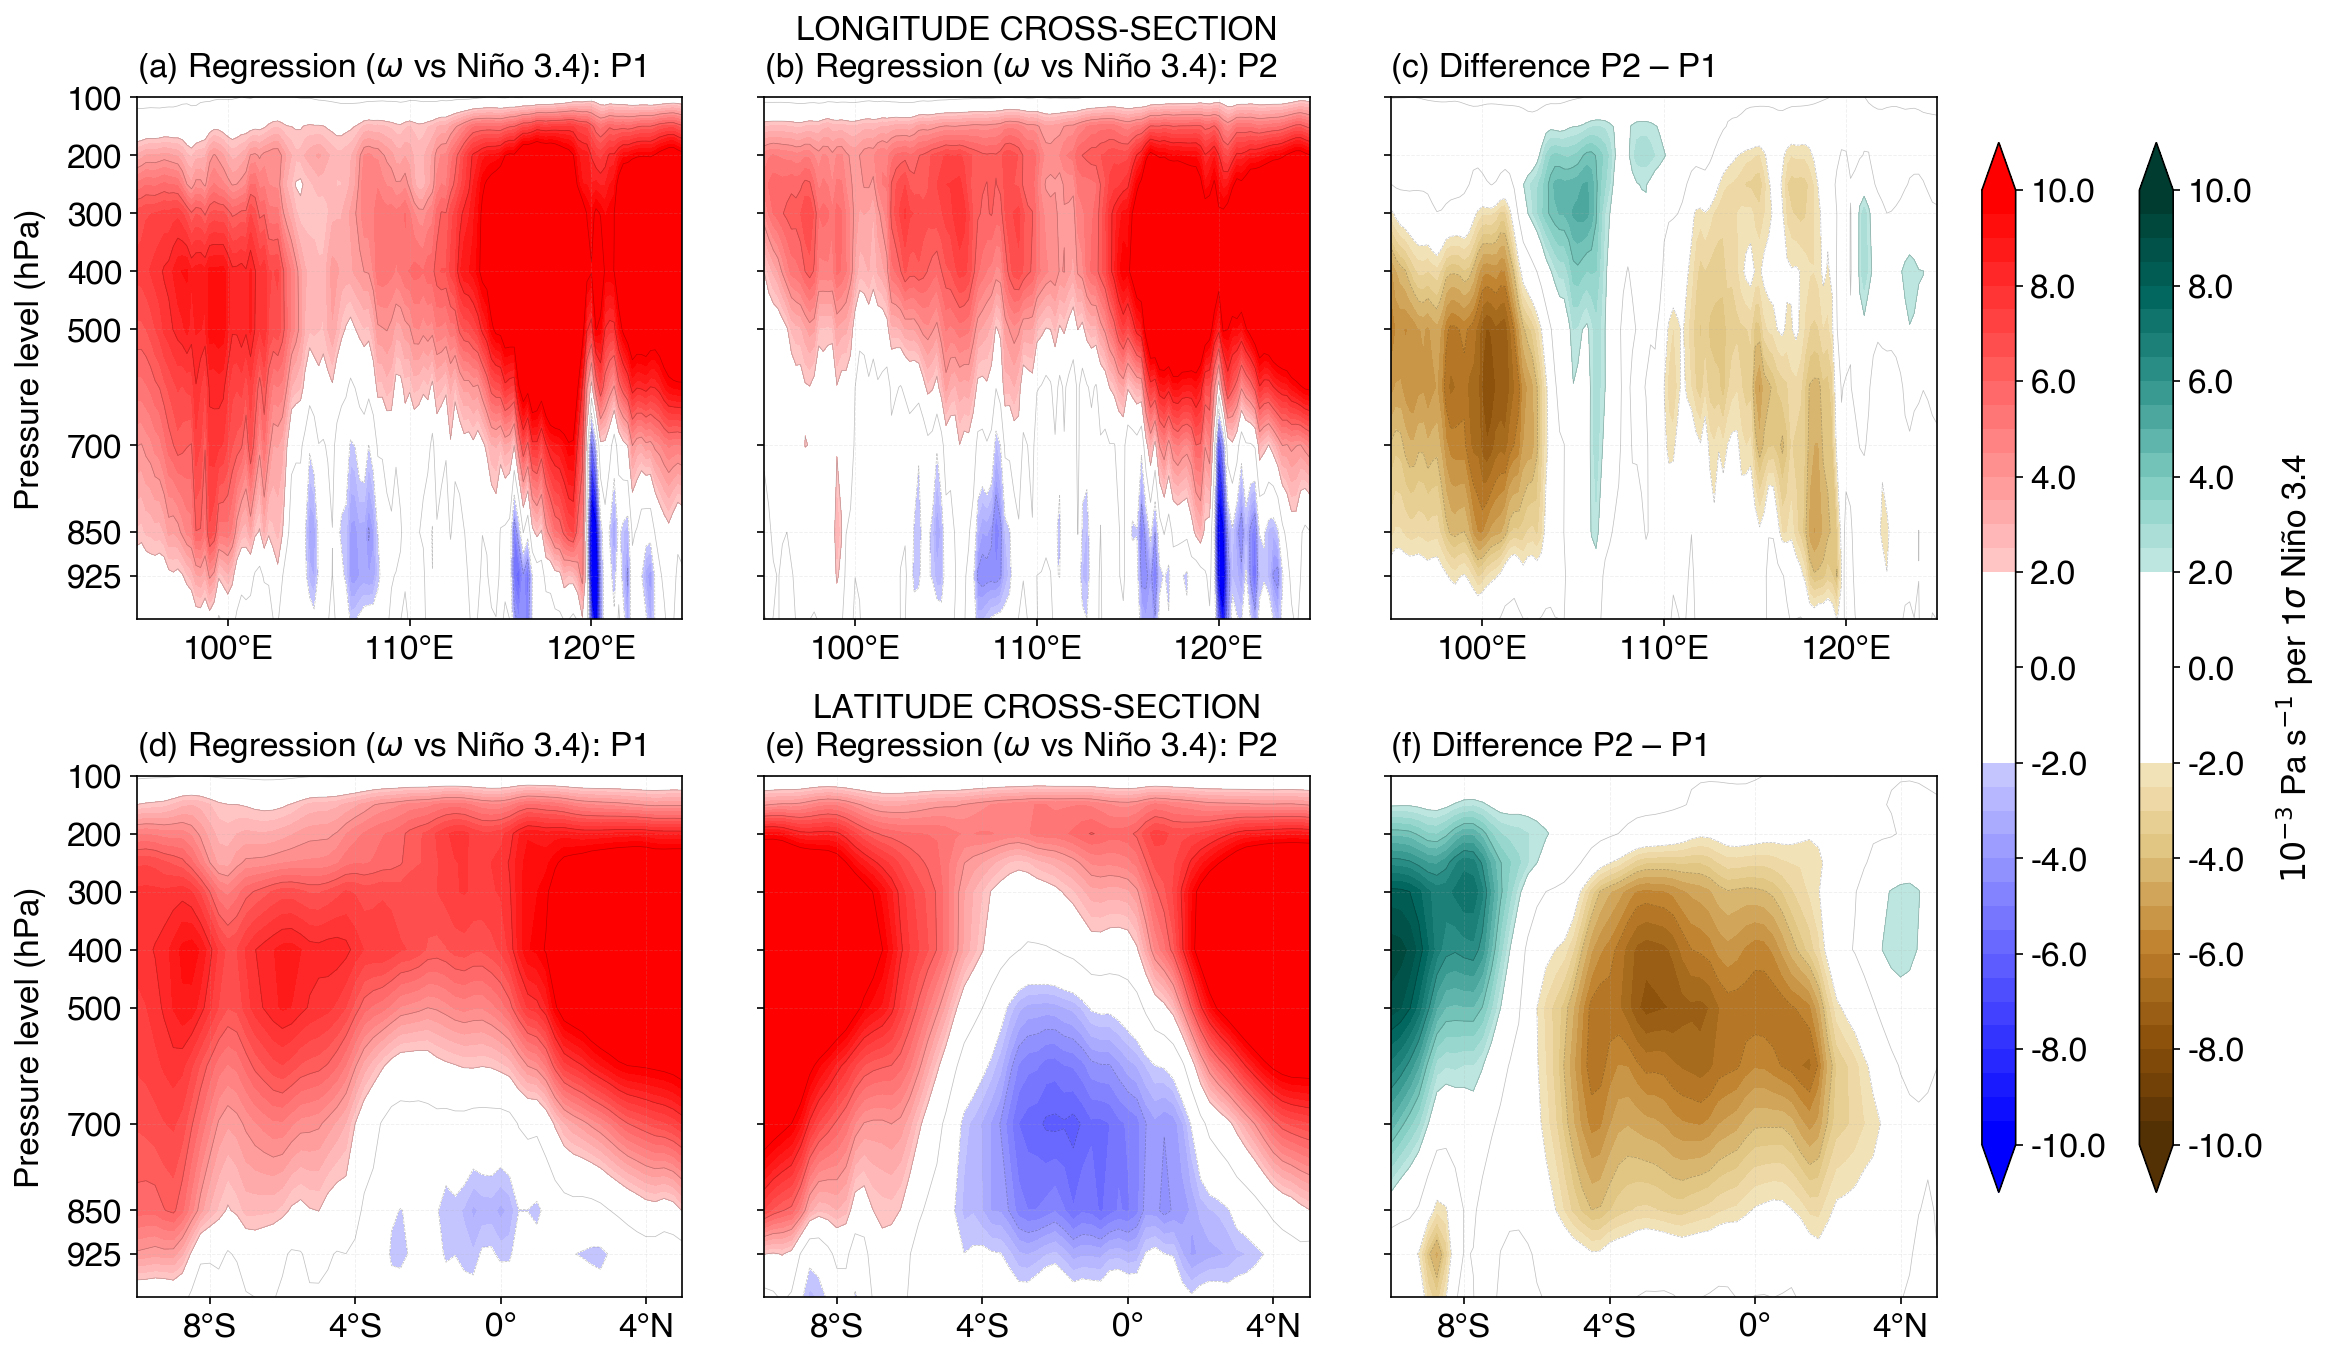

In [3]:
# Plotting parameters for omega
value_scale = 1e3
clevs = contour_levels(-10, 10.1, 0.5)
cticks = np.arange(-10, 10.1, 2)
cbar_ticks = np.arange(-10, 10.1, 2)
cbar_format = FormatStrFormatter('%.1f')
white_band = (-2, 2)

periods = ['p1', 'p2', 'delta']
period_labels_row1 = {
    r'p1': r'(a) Regression ($\omega$ vs Niño 3.4): P1',
    r'p2': r'(b) Regression ($\omega$ vs Niño 3.4): P2',
    'delta': r'(c) Difference P2 – P1',
}
period_labels_row2 = {
    r'p1': r'(d) Regression ($\omega$ vs Niño 3.4): P1',
    r'p2': r'(e) Regression ($\omega$ vs Niño 3.4): P2',
    'delta': r'(f) Difference P2 – P1',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)
levels = np.asarray(clevs)
def build_cmap(base_cmap, levels, white_band=None):
    colors = plt.get_cmap(base_cmap, len(levels) - 1)(np.linspace(0, 1, len(levels) - 1))
    if white_band is not None:
        white_low, white_high = white_band
        band_mask = (levels[:-1] >= white_low) & (levels[1:] <= white_high)
        colors[band_mask] = np.array([1, 1, 1, 1])
    return ListedColormap(colors)

plot_cmap = build_cmap('bwr', levels, white_band=white_band)
delta_cmap = build_cmap('BrBG', levels, white_band=white_band)

row_specs = [
    (lon_omega, LON_BAND, LON_TICKS, format_lon, period_labels_row1),
    (lat_omega, LAT_BAND, LAT_TICKS, format_lat, period_labels_row2),
]

mesh_bwr = None
mesh_delta = None
for row, (row_dict, x_band, x_ticks, formatter, period_labels) in enumerate(row_specs):
    for col, period in enumerate(periods):
        ax = axes[row, col]
        da = row_dict[period]
        x_dim = 'lon' if 'lon' in da.dims else 'lat'
        da2 = da.transpose('level', x_dim)
        values = smooth_2d(da2.values) * value_scale
        x = da2[x_dim].values
        y = da2['level'].values

        cmap = delta_cmap if period == 'delta' else plot_cmap
        mesh = ax.contourf(x, y, values, levels=levels, cmap=cmap, extend='both')
        ax.contour(x, y, values, levels=cticks, colors='k', linewidths=0.35, alpha=0.25)

        ax.set_xlim(x_band.start, x_band.stop)
        ax.set_ylim(1000, 100)
        ax.set_xticks(x_ticks)
        ax.set_yticks(PRESSURE_TICKS)
        ax.xaxis.set_major_formatter(FuncFormatter(formatter))
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True, linestyle='--', alpha=0.18, linewidth=0.45)
        
        if col == 0:
            ax.set_ylabel('Pressure level (hPa)', fontsize=16, labelpad=10)
        else:
            ax.set_ylabel('')
            
        ax.set_title(period_labels[period], loc='left', fontsize=16, pad=10, fontweight='regular')

        if period == 'delta':
            mesh_delta = mesh
        else:
            mesh_bwr = mesh

# Add row titles (explicitly bold)
axes[0, 1].text(0.5, 1.1, 'LONGITUDE CROSS-SECTION', transform=axes[0, 1].transAxes,
                ha='center', va='bottom', fontsize=16, fontweight='bold')
axes[1, 1].text(0.5, 1.1, 'LATITUDE CROSS-SECTION', transform=axes[1, 1].transAxes,
                ha='center', va='bottom', fontsize=16, fontweight='bold')

# Adjust layout to fit row titles and avoid overlap
fig.subplots_adjust(left=0.08, right=0.88, top=0.88, bottom=0.08, wspace=0.15, hspace=0.3)

# Add two vertical colorbars without shrinking the subplot area
cbar_label = r'$10^{-3}$ Pa s$^{-1}$ per 1$\sigma$ Niño 3.4'
cbar_bwr_ax = fig.add_axes([0.900, 0.15, 0.015, 0.70])
cbar_bwr = fig.colorbar(mesh_bwr, cax=cbar_bwr_ax, ticks=cbar_ticks)
cbar_bwr.ax.yaxis.set_major_formatter(cbar_format)
cbar_bwr.ax.yaxis.set_ticks_position('right')
cbar_bwr.ax.tick_params(labelsize=16, labelleft=False, labelright=True)
# The bwr colorbar remains unlabeled because the unit is shared with the delta colorbar.

cbar_delta_ax = fig.add_axes([0.970, 0.15, 0.015, 0.70])
cbar_delta = fig.colorbar(mesh_delta, cax=cbar_delta_ax, ticks=cbar_ticks)
cbar_delta.ax.yaxis.set_major_formatter(cbar_format)
cbar_delta.ax.yaxis.set_ticks_position('right')
cbar_delta.ax.tick_params(labelsize=16, labelleft=False, labelright=True)
cbar_delta.ax.set_ylabel(cbar_label, fontsize=16, rotation=90, labelpad=5)
cbar_delta.ax.yaxis.set_label_position('right')

# Save figure
fig.savefig(RESULTS_DIR / 'cross_sections_reg_omega.png', dpi=300, bbox_inches='tight')
plt.show()
